# 유튜브에서 특정 키워드 분석 > 워드클라우드 시각화

✅ 전체 분석 흐름
검색 키워드 입력

*   YouTube Data API로 인기 영상 검색
*   각 영상의 조회수, 좋아요 수, 제목, 해시태그 수집
*   데이터프레임으로 정리
*   워드클라우드 시각화


#📦 1단계: 필요한 라이브러리 설치 (한 번만 실행)

In [ ]:
!pip install konlpy wordcloud
# 코랩 한글 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

#🛠️ 2단계: 폰트 설정 (한글 깨짐 방지용)

In [ ]:
#세션다시시작

In [ ]:
# 나눔 폰트 설정
import matplotlib.pyplot as plt
# 폰트 설정
plt.rc('font' , family='NanumBarunGothic')

#📊 3단계: 워드클라우드 생성 코드

In [ ]:
!pip install google-api-python-client wordcloud matplotlib

📄 수집된 영상 정보:


,영상제목,조회수,좋아요수,링크,해시태그
0,(광고)인천 영종도 구읍뱃터 대왕조개전골 맛집 조개원칙,6048837,39070,https://www.youtube.com/watch?v=o2YXhWYFp60,
1,"막걸리 한 잔 1,500원에 안주는 무료로 주는 인천 구월동 모래내시장 전집",4076225,39241,https://www.youtube.com/watch?v=4hLorLMYQf0,
2,이영자 추천 잠실 맛집 3대천왕,2158982,20165,https://www.youtube.com/watch?v=uP6S9S7_18c,
3,"박성일 배우의 성북구 맛집 드림랜드 분식. 생활의달인 쫄면과 맛있는 김밥, 떡볶이....",2044409,2857,https://www.youtube.com/watch?v=j3ZNBqPrmew,
4,오픈10분만에 완판되는 만두#서울맛집#창동맛집#만두맛집,882793,5619,https://www.youtube.com/watch?v=yHxCk_zCr0I,
5,"한우 거세 1++ 투쁠 등심 100g 9,900원 김포 풍무동 한우집투뿔사위",776907,2638,https://www.youtube.com/watch?v=q3GSltaNDEY,
6,korean food #먹기 #맛있음 #맛집 #맛있는 #서울 #서울맛집 #경남 #시...,380991,4735,https://www.youtube.com/watch?v=8peSh0sRz4o,
7,서울에서 모르면 손해입니다.,333907,8947,https://www.youtube.com/watch?v=vJT_Hs4VHMI,"서울, 서울맛집, 서울술집, 서울카페, 서울여행, 서울데이트, 서울가볼만한곳, 서울..."
8,서울 주민이 추천하는 숨은 맛집 top7,580508,5435,https://www.youtube.com/watch?v=BJFKbvJBxiM,
9,보시면 도움됩니다. 서울 가성비맛집 3군데 모음!,540696,4258,https://www.youtube.com/watch?v=e6RqIfoyVVc,"서울맛집, 가성비맛집, 서울가성비맛집, 서울맛집추천, 양꼬치무한리필"


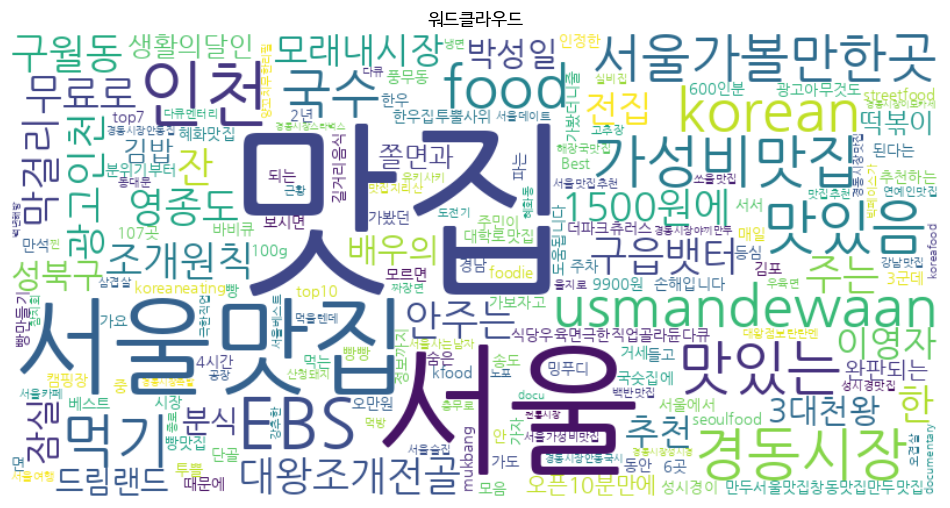

In [ ]:
import warnings
warnings.filterwarnings('ignore')  # 모든 경고 숨기기

import logging
logging.getLogger('matplotlib.font_manager').disabled = True  # 폰트 관련 로그 숨기기
#---

from googleapiclient.discovery import build
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re


# 🔑 유튜브 API 키 입력
api_key = "유튜브 API"  # ← 여기에 본인의 API 키를 입력

# 🔍 검색어 설정
search_query = "서울 맛집"

# 📅 최근 3개월 기준 날짜 계산 (RFC 3339 형식)
from datetime import datetime, timedelta
published_after = (datetime.now() - timedelta(days=90)).isoformat("T") + "Z"

# 🔧 YouTube API 클라이언트 생성
youtube = build('youtube', 'v3', developerKey=api_key)

# 📥 영상 검색 > search.list() 메서드를 이용해 검색 결과(영상 목록) 를 받아오는 코드
search_response = youtube.search().list(
    q=search_query,
    part='snippet',
    maxResults=20,
    type='video',
    publishedAfter=published_after,
    order='viewCount'
).execute()

# 📺 영상 ID 추출
video_ids = [item['id']['videoId'] for item in search_response['items']]

# 📊 영상 통계 및 상세정보 요청
video_response = youtube.videos().list(
    part='snippet,statistics',
    id=','.join(video_ids)
).execute()

video_data = []

for item in video_response['items']:
    title = item['snippet']['title']
    video_id = item['id']
    views = int(item['statistics'].get('viewCount', 0))
    likes = int(item['statistics'].get('likeCount', 0))
    tags = item['snippet'].get('tags', [])  # 해시태그는 있을 수도 있고 없을 수도 있음
    link = f"https://www.youtube.com/watch?v={video_id}"

    video_data.append({
        '영상제목': title,
        '조회수': views,
        '좋아요수': likes,
        '링크': link,
        '해시태그': ", ".join(tags)
    })

# 📊 DataFrame으로 정리
df = pd.DataFrame(video_data)
print("📄 수집된 영상 정보:")
display(df[['영상제목', '조회수', '좋아요수', '링크', '해시태그']])

# 📌 워드클라우드를 위한 텍스트 데이터 통합
all_text = " ".join(df['영상제목']) + " " + " ".join(df['해시태그'])
all_text = re.sub(r"[^\uAC00-\uD7A3a-zA-Z0-9\s]", "", all_text)  # 특수문자 제거

# 🌈 워드클라우드 생성
wordcloud = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',  # 한글 폰트 경로 (Colab 환경 기준)
    background_color='white',
    width=800,
    height=400
).generate(all_text)

# 📈 워드클라우드 시각화
plt.figure(figsize=(12, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f"워드클라우드", fontsize=13)
plt.show()

### 🔍 interpolation이란?
<br>
이미지를 화면에 그릴 때, 원래 해상도보다 크거나 작게 표시해야 하는 경우<br> 픽셀 간 값을 보간(interpolate) 해서 자연스럽게 보여주는 방식<br>


📌 주요 옵션 설명:<br>

| 옵션           | 설명                                        |
| ------------ | ----------------------------------------- |
| `'nearest'`  | 가장 가까운 픽셀의 색상으로 표시 (계단현상 있음, 빠름)          |
| `'bilinear'` | 주변 4개의 픽셀 값을 평균해서 부드럽게 표시 (자연스러움)         |
| `'bicubic'`  | 주변 16개의 픽셀 값을 사용해 더 부드럽게 표시 (가장 부드럽지만 느림) |

###📌 파라미터 설명

| 파라미터                             | 설명                                                 |
| -------------------------------- | -------------------------------------------------- |
| `q=search_query`                 | 검색할 키워드 (예: `"서울 맛집"`)                             |
| `part='snippet'`                 | 어떤 정보들을 가져올지 지정. `snippet`은 영상의 제목, 설명, 채널명, 게시일 등 |
| `maxResults=20`                  | 최대 몇 개의 결과를 가져올지 (최대 50까지 가능)                      |
| `type='video'`                   | 영상만 가져오도록 지정 (채널이나 재생목록 제외)                        |
| `publishedAfter=published_after` | 이 날짜 이후에 게시된 영상만 가져오기 (예: 최근 3개월 기준)               |
| `order='viewCount'`              | 정렬 방식: 조회수 기준 내림차순 정렬                              |




---



#🔍 분석으로 알 수 있는 것들


*   조회수/좋아요수가 높은 영상들: 어떤 콘텐츠가 최근에 인기가 있었는지 파악
*   자주 쓰인 단어/해시태그: 사람들이 많이 검색하거나 반응한 키워드 분석 → 콘텐츠 아이디어
- 영상 링크 수집: 직접 참고하거나 분석용 자료로 활용 가능





